# User-User Collaborative Filtering on MovieLens 100K

This notebook implements a fast user-user CF using sparse matrices and sklearn NearestNeighbors, evaluates RMSE/MAE and Precision/Recall@K, and plots results.

In [1]:
# 1 — Setup & imports
import os
import zipfile
import urllib.request
from pathlib import Path
import numpy as np
import pandas as pd
from math import sqrt
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.neighbors import NearestNeighbors
from scipy import sparse
import matplotlib.pyplot as plt
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

# Notebook plotting magic
%matplotlib inline

# Config
DATA_URL = 'https://files.grouplens.org/datasets/movielens/ml-100k.zip'
DATA_DIR = Path('./ml-100k')
RATING_FILE = DATA_DIR / 'u.data'
TEST_FRAC = 0.2
K_NEIGHBORS_FAST = 20
NN_PRECOMPUTE = K_NEIGHBORS_FAST + 1
TOPN = 10
SEED = 42
np.random.seed(SEED)


In [2]:
# 2 — Download MovieLens (if missing) and load ratings
if not DATA_DIR.exists() or not RATING_FILE.exists():
    print('Downloading MovieLens 100K...')
    zip_path = Path('ml-100k.zip')
    urllib.request.urlretrieve(DATA_URL, zip_path)
    with zipfile.ZipFile(zip_path, 'r') as z:
        z.extractall('.')
    zip_path.unlink()
    print('Downloaded.')
else:
    print('MovieLens found at', DATA_DIR)

cols = ['user_id', 'item_id', 'rating', 'timestamp']
ratings = pd.read_csv(RATING_FILE, sep='\t', names=cols, engine='python')
ratings = ratings.drop(columns=['timestamp'])
ratings['user'] = 'u' + ratings['user_id'].astype(str)
ratings['item'] = 'i' + ratings['item_id'].astype(str)
ratings = ratings[['user', 'item', 'rating']]
print(f"Loaded {len(ratings)} ratings: {ratings['user'].nunique()} users, {ratings['item'].nunique()} items")

Downloaded.
Loaded 100000 ratings: 943 users, 1682 items


In [3]:
# 3 — Train/test split per user
def train_test_split_per_user(df, test_frac=0.2, seed=42):
    np.random.seed(seed)
    train_list = []
    test_list = []
    for u, g in df.groupby('user'):
        g_shuf = g.sample(frac=1.0, random_state=seed)
        n = len(g_shuf)
        if n == 0:
            continue
        test_n = max(1, int(np.floor(n * test_frac)))
        test_list.append(g_shuf.iloc[:test_n])
        if n - test_n > 0:
            train_list.append(g_shuf.iloc[test_n:])
    train_df = pd.concat(train_list).reset_index(drop=True) if train_list else pd.DataFrame(columns=df.columns)
    test_df = pd.concat(test_list).reset_index(drop=True) if test_list else pd.DataFrame(columns=df.columns)
    return train_df, test_df

train_df, test_df = train_test_split_per_user(ratings, test_frac=TEST_FRAC, seed=SEED)
print(f"Train ratings: {len(train_df)}, Test ratings: {len(test_df)}")

Train ratings: 80367, Test ratings: 19633


In [4]:
# 4 — Build index maps and sparse user-item matrix
all_users = sorted(ratings['user'].unique())
all_items = sorted(ratings['item'].unique())
user_to_idx = {u: i for i, u in enumerate(all_users)}
item_to_idx = {it: i for i, it in enumerate(all_items)}
rows = train_df['user'].map(user_to_idx).astype(int).values
cols = train_df['item'].map(item_to_idx).astype(int).values
data = train_df['rating'].astype(float).values
n_users = len(all_users)
n_items = len(all_items)
R_csr = sparse.csr_matrix((data, (rows, cols)), shape=(n_users, n_items))
print('CSR matrix:', R_csr.shape, ' nnz=', R_csr.nnz)

# Precompute user means and global mean for fallbacks
user_means = train_df.groupby('user')['rating'].mean().to_dict()
global_mean = train_df['rating'].mean()

CSR matrix: (943, 1682)  nnz= 80367


In [5]:
# 5 — Fit NearestNeighbors and precompute neighbors
print('Fitting NearestNeighbors...')
nn = NearestNeighbors(n_neighbors=NN_PRECOMPUTE, metric='cosine', algorithm='auto', n_jobs=-1)
nn.fit(R_csr)
print('Computing kneighbors...')
distances, indices = nn.kneighbors(R_csr, return_distance=True)
similarities = 1.0 - distances

clean_neighbors = [None] * n_users
clean_sims = [None] * n_users
for u_idx in range(n_users):
    neigh = indices[u_idx]
    sims = similarities[u_idx]
    mask = neigh != u_idx
    neigh2 = neigh[mask]
    sims2 = sims[mask]
    neigh2 = neigh2[:K_NEIGHBORS_FAST]
    sims2 = sims2[:K_NEIGHBORS_FAST]
    clean_neighbors[u_idx] = neigh2
    clean_sims[u_idx] = sims2
print('Precomputed neighbors for all users.')

Fitting NearestNeighbors...
Computing kneighbors...
Precomputed neighbors for all users.


In [6]:
# 6 — Precompute item -> raters mapping
item_to_raters = {}
for item, g in train_df.groupby('item'):
    u_idx_arr = g['user'].map(user_to_idx).astype(int).values
    r_arr = g['rating'].astype(float).values
    item_to_raters[item] = (u_idx_arr, r_arr)
print('Built item->raters mapping for', len(item_to_raters), 'items.')

Built item->raters mapping for 1651 items.


In [7]:
# 7 — Fast prediction function
def predict_rating_fast(user, item, shrinkage=0.0):
    if user not in user_to_idx or item not in item_to_idx:
        return np.nan
    u_idx = user_to_idx[user]
    neigh_idxs = clean_neighbors[u_idx]
    neigh_sims = clean_sims[u_idx]
    if item not in item_to_raters:
        return np.nan
    raters_idx, raters_ratings = item_to_raters[item]
    if raters_idx.size == 0:
        return np.nan
    raters_set = set(raters_idx.tolist())
    mask = np.array([int(n) in raters_set for n in neigh_idxs])
    if not mask.any():
        return np.nan
    chosen_neighs = neigh_idxs[mask]
    chosen_sims = neigh_sims[mask]
    rmap = {int(u): float(r) for u, r in zip(raters_idx, raters_ratings)}
    neigh_ratings = np.array([rmap[int(n)] for n in chosen_neighs])
    denom = np.abs(chosen_sims).sum() + shrinkage
    if denom == 0:
        return np.nan
    pred = (chosen_sims * neigh_ratings).sum() / denom
    return pred

# Quick sanity check on a few known test rows
for _, row in test_df.head(5).iterrows():
    u, it, r = row['user'], row['item'], row['rating']
    print(f"user={u}, item={it}, true={r}, pred={predict_rating_fast(u, it)}")

user=u1, item=i31, true=3, pred=3.1806436550353943
user=u1, item=i39, true=4, pred=3.005875691025767
user=u1, item=i163, true=4, pred=3.8356973366423697
user=u1, item=i226, true=3, pred=3.2256012679840023
user=u1, item=i169, true=5, pred=4.833496766280945


In [8]:
# 8 — Evaluate RMSE / MAE
def evaluate_predictions_fast(test_df):
    y_true = []
    y_pred = []
    for _, row in test_df.iterrows():
        u, it, r = row['user'], row['item'], row['rating']
        p = predict_rating_fast(u, it)
        if np.isnan(p):
            p = user_means.get(u, global_mean)
        y_true.append(r)
        y_pred.append(p)
    rmse = sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    return {'rmse': rmse, 'mae': mae, 'n': len(y_true)}

res_fast = evaluate_predictions_fast(test_df)
print('Rating prediction (fast):', res_fast)

Rating prediction (fast): {'rmse': 1.0736103528433045, 'mae': 0.8407547704781173, 'n': 19633}


In [9]:
# 9 — Top-N: Precision@K, Recall@K
def recommend_top_k_fast(user, top_n=TOPN):
    if user not in user_to_idx:
        return []
    seen_items = set(train_df[train_df['user'] == user]['item'])
    candidate_items = [it for it in all_items if it not in seen_items]
    scores = []
    for it in candidate_items:
        s = predict_rating_fast(user, it)
        scores.append((it, s if not np.isnan(s) else -999))
    scores.sort(key=lambda x: x[1], reverse=True)
    return [it for it, _ in scores[:top_n]]

def precision_recall_at_k_fast(test_df, top_n=TOPN):
    users_common = sorted(set(train_df['user']).intersection(set(test_df['user'])))
    precisions = []
    recalls = []
    for u in users_common:
        true_items = set(test_df[test_df['user'] == u]['item'])
        if len(true_items) == 0:
            continue
        recs = recommend_top_k_fast(u, top_n=top_n)
        hit = len(set(recs) & true_items)
        precisions.append(hit / top_n)
        recalls.append(hit / len(true_items))
    return {'precision_at_{}'.format(top_n): np.mean(precisions) if precisions else 0.0,
            'recall_at_{}'.format(top_n): np.mean(recalls) if recalls else 0.0,
            'users_eval': len(precisions)}

prec_fast = precision_recall_at_k_fast(test_df, top_n=TOPN)
print('Top-N (fast):', prec_fast)

Top-N (fast): {'precision_at_10': np.float64(0.01707317073170732), 'recall_at_10': np.float64(0.020679585449809523), 'users_eval': 943}


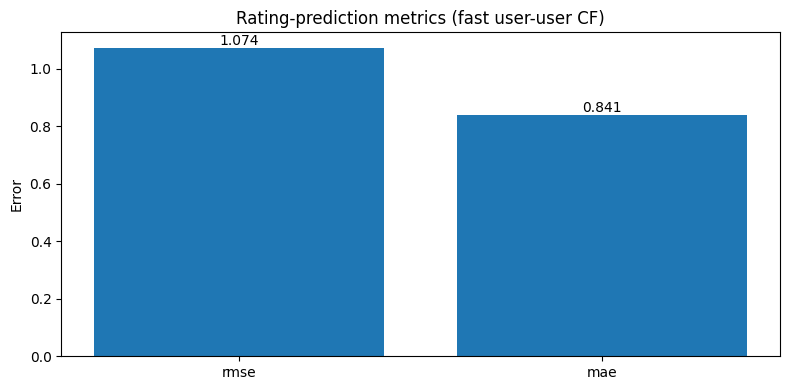

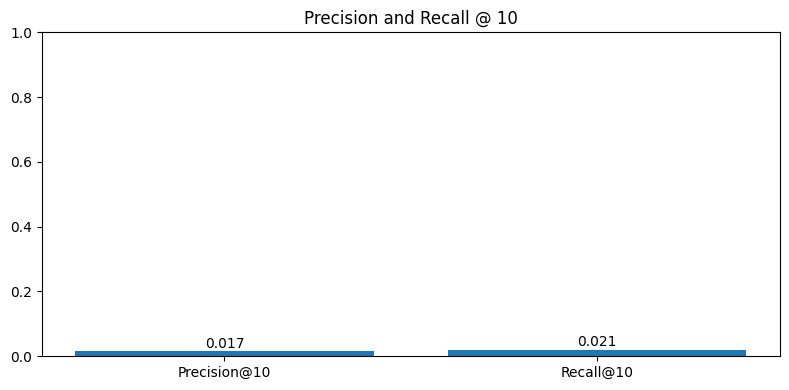

In [10]:
# 10 — Plots: RMSE/MAE and Precision/Recall
metrics_names = ['rmse', 'mae']
metrics_values = [res_fast['rmse'], res_fast['mae']]

plt.figure(figsize=(8,4))
plt.bar(metrics_names, metrics_values)
plt.title('Rating-prediction metrics (fast user-user CF)')
plt.ylabel('Error')
for i, v in enumerate(metrics_values):
    plt.text(i, v + 0.01, f"{v:.3f}", ha='center')
plt.tight_layout()
plt.show()

pr_names = [f'Precision@{TOPN}', f'Recall@{TOPN}']
pr_values = [prec_fast[f'precision_at_{TOPN}'], prec_fast[f'recall_at_{TOPN}']]

plt.figure(figsize=(8,4))
plt.bar(pr_names, pr_values)
plt.title(f'Precision and Recall @ {TOPN}')
plt.ylim(0, 1)
for i, v in enumerate(pr_values):
    plt.text(i, v + 0.01, f"{v:.3f}", ha='center')
plt.tight_layout()
plt.show()

In [11]:
# 11 — Save evaluation summary and example recommendations
summary = pd.DataFrame([{'method': 'user-user (fast, cosine NN)', **res_fast, **prec_fast}])
summary.to_csv('uu_cf_movielens_fast_eval_summary.csv', index=False)
print('Saved summary to uu_cf_movielens_fast_eval_summary.csv')

# Show example recommendations for first 5 users
for u in all_users[:5]:
    recs = recommend_top_k_fast(u, top_n=5)
    print(f'user={u}, recs={recs}')

Saved summary to uu_cf_movielens_fast_eval_summary.csv
user=u1, recs=['i1093', 'i1111', 'i1114', 'i613', 'i675']
user=u10, recs=['i109', 'i1195', 'i1199', 'i1428', 'i305']
user=u100, recs=['i1025', 'i1175', 'i337', 'i345', 'i361']
user=u101, recs=['i10', 'i1277', 'i173', 'i216', 'i249']
user=u102, recs=['i1019', 'i1119', 'i116', 'i124', 'i137']
